In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create a project folder in your Drive
os.makedirs('/content/drive/MyDrive/olist_project', exist_ok=True)

# Copy uploaded files to Drive so you never need to re-upload
import shutil
for filename in ['olist_orders_dataset.csv', 'olist_order_items_dataset.csv',
                 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv',
                 'olist_products_dataset.csv', 'olist_customers_dataset.csv']:
    shutil.copy(f'/content/{filename}', f'/content/drive/MyDrive/olist_project/{filename}')

print("All files saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive!


In [ ]:
path = '/content/drive/MyDrive/olist_project/'

orders    = pd.read_csv(path + 'olist_orders_dataset.csv')
items     = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products  = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')

print("All files loaded successfully!")

All files loaded successfully!


In [ ]:
print("Order Statuses before filtering:")
print(orders['order_status'].value_counts())

orders_delivered=orders[orders['order_status']=='delivered'].copy()

print(f"\nBefore: {len(orders)} orders")
print(f"After: {len(orders_delivered)} orders")
print(f"Dropped: {len(orders)-len(orders_delivered)} orders")



Order Statuses before filtering:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Before: 99441 orders
After: 96478 orders
Dropped: 2963 orders


In [ ]:
orders_delivered['order_purchase_timestamp']=pd.to_datetime(orders_delivered['order_purchase_timestamp'])
orders_delivered['order_delivered_customer_date'] = pd.to_datetime(orders_delivered['order_delivered_customer_date'])

print("Date colums converted succesfully!")
print(orders_delivered[['order_purchase_timestamp','order_delivered_customer_date']].dtypes)


Date colums converted succesfully!
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


In [ ]:
#orders+customers
df=orders_delivered.merge(customers,on='customer_id',how='left')

payments_agg=payments.groupby('order_id')['payment_value'].sum().reset_index()
df=df.merge(payments_agg,on='order_id',how='left')

reviews_clean=reviews[['order_id','review_score']].drop_duplicates(subset='order_id')
df=df.merge(reviews_clean,on='order_id',how='left')

items_agg=items.groupby('order_id')['price'].sum().reset_index()
items_agg.rename(columns={'price':'total_item_price'},inplace=True)
df=df.merge(items_agg,on='order_id',how='left')

print(f"Master table shape: {df.shape}")
print(f"Columns:{list(df.columns)}")

Master table shape: (96478, 15)
Columns:['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_value', 'review_score', 'total_item_price']


In [ ]:
reference_date=df['order_purchase_timestamp'].max()+pd.Timedelta(days=1)
print(f"Reference Date:{reference_date}")

rfm=df.groupby('customer_unique_id').agg(
    first_purchase=('order_purchase_timestamp','min'),
    last_purchase=('order_purchase_timestamp','max'),
    frequency=('order_id','count'),
    monetary=('payment_value','sum'),
    avg_review=('review_score','mean')
).reset_index()

rfm['recency']=(reference_date - rfm['last_purchase']).dt.days

print(f"\nRFM table shape:{rfm.shape}")
print(rfm.head())

Reference Date:2018-08-30 15:00:37

RFM table shape:(93358, 7)
                 customer_unique_id      first_purchase       last_purchase  \
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27 2018-05-10 10:56:27   
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27 2018-05-07 11:11:27   
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03 2017-03-10 21:05:03   
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41 2017-10-12 20:29:41   
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42 2017-11-14 19:45:42   

   frequency  monetary  avg_review  recency  
0          1    141.90         5.0      112  
1          1     27.19         4.0      115  
2          1     86.22         3.0      537  
3          1     43.62         4.0      321  
4          1    196.89         5.0      288  


In [ ]:
rfm['churned'] = (rfm['frequency'] == 1).astype(int)

print("Churn distribution:")
print(rfm['churned'].value_counts())
print(f"\nChurn rate: {rfm['churned'].mean()*100:.1f}%")

Churn distribution:
churned
1    90557
0     2801
Name: count, dtype: int64

Churn rate: 97.0%


In [ ]:
rfm['R_score']=pd.qcut(rfm['recency'],q=4,labels=[4,3,2,1]).astype(int)
rfm['F_score']=pd.qcut(rfm['frequency'].rank(method='first'),q=4,labels=[1,2,3,4]).astype(int)
rfm['M_score']=pd.qcut(rfm['monetary'].rank(method='first'),q=4,labels=[1,2,3,4]).astype(int)

rfm['RFM_score']=rfm['R_score']+rfm['F_score']+rfm['M_score']
print("RFM Score distribution:")
print(rfm['RFM_score'].value_counts().sort_index())

RFM Score distribution:
RFM_score
3      1519
4      4578
5      8971
6     14486
7     17455
8     16929
9     14173
10     8874
11     4592
12     1781
Name: count, dtype: int64


In [ ]:
def assign_segment(row):
  r,f,m=row['R_score'],row['F_score'],row['M_score']
  if r>=4 and f>=3 and m>=3:
    return 'Champion'
  elif r>=3 and f>=2:
    return 'Loyal'
  elif r>=2 and f==1:
    return 'Promising'
  elif r==2 and f>=2:
    return 'At risk'
  elif r<=2 and f==1 and m>=3:
    return 'High Value Lost'
  else:
    return 'Lost'

rfm['segment']=rfm.apply(assign_segment,axis=1)
print("Customer Segments:")
print(rfm['segment'].value_counts())
print(f"\nTotal customers: {len(rfm)}")



Customer Segments:
segment
Loyal              29041
Lost               20450
Promising          17440
At risk            17437
Champion            6129
High Value Lost     2861
Name: count, dtype: int64

Total customers: 93358


In [ ]:
print("Nulls in RFM table:")
print(rfm.isnull().sum())

Nulls in RFM table:
customer_unique_id      0
first_purchase          0
last_purchase           0
frequency               0
monetary                0
avg_review            603
recency                 0
churned                 0
R_score                 0
F_score                 0
M_score                 0
RFM_score               0
segment                 0
dtype: int64


In [ ]:
rfm['avg_review'].fillna(rfm['avg_review'].median(),inplace=True)
print("\nAfter filling nulls:")
print(rfm.isnull().sum())


After filling nulls:
customer_unique_id    0
first_purchase        0
last_purchase         0
frequency             0
monetary              0
avg_review            0
recency               0
churned               0
R_score               0
F_score               0
M_score               0
RFM_score             0
segment               0
dtype: int64


/tmp/ipykernel_331/1198392554.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rfm['avg_review'].fillna(rfm['avg_review'].median(),inplace=True)


In [ ]:
print("=== PROJECT HEADLINE NUMBERS ===")
print(f"Total unique customers:     {len(rfm):,}")
print(f"Churned customers:          {rfm['churned'].sum():,}")
print(f"Active customers:           {(rfm['churned']==0).sum():,}")
print(f"Overall churn rate:         {rfm['churned'].mean()*100:.1f}%")
print(f"Avg customer spend:         ${rfm['monetary'].mean():.2f}")
print(f"Avg review score:           {rfm['avg_review'].mean():.2f} / 5")
print(f"\nSegment breakdown:")
print(rfm['segment'].value_counts())

=== PROJECT HEADLINE NUMBERS ===
Total unique customers:     93,358
Churned customers:          90,557
Active customers:           2,801
Overall churn rate:         97.0%
Avg customer spend:         $165.20
Avg review score:           4.16 / 5

Segment breakdown:
segment
Loyal              29041
Lost               20450
Promising          17440
At risk            17437
Champion            6129
High Value Lost     2861
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

features=['recency','frequency','monetary','avg_review','R_score','F_score','M_score','RFM_score']

X=rfm[features]
y=rfm['churned']

print("Featured matrix shape:",X.shape)
print("Target variable shape",y.shape)
print("\nAny nulls in features?")
print(X.isnull().sum())

Featured matrix shape: (93358, 8)
Target variable shape (93358,)

Any nulls in features?
recency       0
frequency     0
monetary      0
avg_review    0
R_score       0
F_score       0
M_score       0
RFM_score     0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training Set: {X_train.shape[0]:,}customers")
print(f"Testing SeT: {X_test.shape[0]:,}customers")
print(f"\nChurn Rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn Rate in testing: {y_test.mean()*100:.1f}%")

Training Set: 74,686customers
Testing SeT: 18,672customers

Churn Rate in training: 97.0%
Churn Rate in testing: 97.0%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Use ONLY raw behavioural features — no RFM scores
# because those scores were derived from the same data we used to define churn
features = ['recency', 'monetary', 'avg_review']

# We remove 'frequency' too because churn = frequency of 1
# Using frequency to predict churn would be like using the answer to predict itself

X = rfm[features]
y = rfm['churned']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train model
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"                  Predicted Active  Predicted Churned")
print(f"Actual Active:        {cm[0][0]}              {cm[0][1]}")
print(f"Actual Churned:       {cm[1][0]}             {cm[1][1]}")

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

      Active       0.09      0.59      0.15       560
     Churned       0.98      0.81      0.89     18112

    accuracy                           0.80     18672
   macro avg       0.54      0.70      0.52     18672
weighted avg       0.96      0.80      0.86     18672

Confusion Matrix:
                  Predicted Active  Predicted Churned
Actual Active:        330              230
Actual Churned:       3525             14587

ROC-AUC Score: 0.783


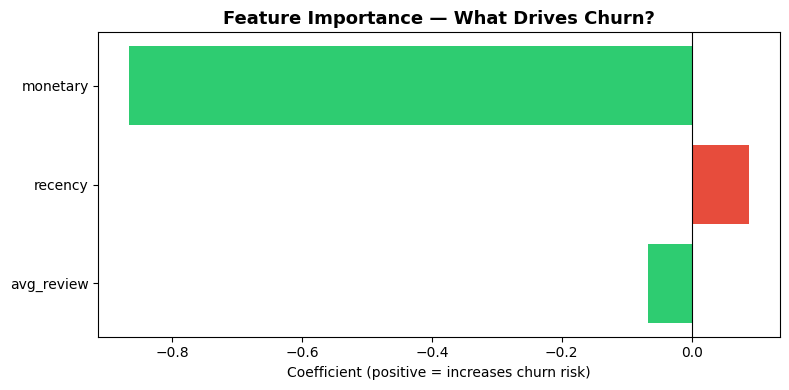


Feature Coefficients:
   feature  coefficient
avg_review    -0.066632
   recency     0.088324
  monetary    -0.865492


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the coefficient for each feature
# In logistic regression, higher coefficient = stronger influence on prediction
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=True)

# Plot
plt.figure(figsize=(8,4))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance — What Drives Churn?', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (positive = increases churn risk)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Coefficients:")
print(feature_importance[['feature','coefficient']].to_string(index=False))

In [ ]:
# Add churn probability score to each customer
# This is the model's confidence that each customer will churn
# 0.95 means 95% likely to churn, 0.20 means 20% likely

rfm['churn_probability'] = model.predict_proba(
    scaler.transform(rfm[features])
)[:,1]

# Create a churn risk category for easier dashboard filtering
def risk_label(prob):
    if prob >= 0.80:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

rfm['churn_risk'] = rfm['churn_probability'].apply(risk_label)

print("Churn Risk Distribution:")
print(rfm['churn_risk'].value_counts())
print(f"\nSample of final table:")
print(rfm[['customer_unique_id','segment','churn_probability','churn_risk','monetary','recency']].head(10))

Churn Risk Distribution:
churn_risk
Medium Risk    74434
Low Risk       18924
Name: count, dtype: int64

Sample of final table:
                 customer_unique_id          segment  churn_probability  \
0  0000366f3b9a7992bf8c76cfdf3221e2        Promising           0.537968   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        Promising           0.657482   
2  0000f46a3911fa3c0805444483337064             Lost           0.672393   
3  0000f6ccb0745a6a4b88665a16c9f078        Promising           0.669839   
4  0004aac84e0df4da2b147fca70cf8255        Promising           0.510056   
5  0004bd2a26a76fe21f786e4fbd80607f        Promising           0.531584   
6  00050ab1314c0e55a6ca13cf7181fecf        Promising           0.652510   
7  00053a61a98854899e70ed204dd4bafe        Promising           0.337120   
8  0005e1862207bf6ccc02e4228effd9a0  High Value Lost           0.603930   
9  0005ef4cd20d2893f0d9fbd94d3c0d97        Promising           0.608651   

    churn_risk  monetary  recency  
0  Medium 

In [ ]:
rfm['churn_probability'] = model.predict_proba(
    scaler.transform(rfm[features])
)[:,1]

def risk_label(prob):
    if prob >= 0.80:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

rfm['churn_risk'] = rfm['churn_probability'].apply(risk_label)
print("Done! Churn risk added.")
print(rfm['churn_risk'].value_counts())

Done! Churn risk added.
churn_risk
Medium Risk    74434
Low Risk       18924
Name: count, dtype: int64


In [ ]:
rfm.to_csv('olist_rfm_final.csv', index=False)

from google.colab import files
files.download('olist_rfm_final.csv')

print("Downloaded! Columns:")
print(list(rfm.columns))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Columns:
['customer_unique_id', 'first_purchase', 'last_purchase', 'frequency', 'monetary', 'avg_review', 'recency', 'churned', 'R_score', 'F_score', 'M_score', 'RFM_score', 'segment', 'churn_probability', 'churn_risk']
